# Prepare the building archetypes

## Read before you start

Run this notebook after `BEM4AI_1_Cities.ipynb`. It does two things, in two parts:

1. **The building stock reference tables.** The Hotmaps building-stock export is reshaped into six
   small tables: countries, building types, age classes, elements, cities, and one `materials` row
   x.
2. **The Honeybee constructions.** Those U-values are turned into Honeybee materials and
   constructions, one per archetype element, sized so the assembly reaches the reported U-value.

An **archetype element** - the unit this whole notebook is keyed on - is one wall, roof, floor or
window, for one building type, of one age class, in one country. The stock describes 6,272 of them.

The two parts were separate notebooks once. They are together because the second is meaningless
without the first: nothing is written to disk until both have passed their checks, so there is no
half-finished artifact to reason about.

Everything is rebuilt from source on every run. The one output, `data/interim/archetypes.pkl`, is
read by `BEM4AI_5_BEMModels.ipynb`.

Energy-demand indicators and the heating, cooling and hot-water system descriptions in the source
table are outside this workflow and are not retained.

## Required inputs

| Input file | Download | Expected location | Used for |
|---|---|---|---|
| `building_stock.csv` | [Hotmaps building stock data](https://gitlab.com/hotmaps/building-stock/-/tree/master/data) | `data/building_stock/building_stock.csv` | Country list, building typologies, age classes, envelope U-values, and the reported construction of each element. |
| `city_assets_df.pkl` | Produced by `BEM4AI_1_Cities.ipynb` | `data/interim/city_assets_df.pkl` | City names, coordinates, countries, and source-asset paths used to build the `cities` lookup table. |

The building-stock table is a pipe-separated CSV of roughly 64,000 rows covering EU27 and the
United Kingdom. It is not redistributed with this repository; download it once from the Hotmaps
repository and place it at the location above.

## Required packages

`honeybee-energy-standards` supplies the opaque material and construction templates Part 2 starts
from. Its pinned version is part of the generation method, so install the project environment
rather than a newer release:

```bash
python -m pip install -r requirements.txt
```

## Source and citation

The building stock table is the open data set published by the Hotmaps project. When using it, cite:

> Simon Pezzutto, Stefano Zambotti, Silvia Croce, Pietro Zambelli, Giulia Garegnani, Chiara Scaramuzzino, Ramón Pascual Pascuas, Alyona Zubaryeva, Franziska Haas, Dagmar Exner (EURAC), Andreas Müller (e-think), Michael Hartner (TUW), Tobias Fleiter, Anna-Lena Klingler, Matthias Kühnbach, Pia Manz, Simon Marwitz, Matthias Rehfeldt, Jan Steinbach, Eftim Popovski (Fraunhofer ISI). Reviewed by Lukas Kranzl, Sara Fritz (TUW). *Hotmaps Project, D2.3 WP2 Report – Open Data Set for the EU28*, 2018. [www.hotmaps-project.eu](https://www.hotmaps-project.eu)

The country list in that file also defines the scope of the dataset: cities in countries without building-stock data are dropped when the `cities` table is built.


# Part 1 - The building stock reference tables

The Hotmaps table is a long, sparse export: one row per country, building type, age class, topic
and feature. This part reshapes it into six small tables keyed by integer ids - four dimensions,
the cities, and one `materials` row per archetype element carrying its U-value and the construction
the stock reports for it. Part 2 then turns those U-values into Honeybee constructions.

Throughout, an **archetype element** is one row of that last table: one wall, roof, floor or
window, for one building type, of one age class, in one country. It is the unit everything here is
keyed on, and the unit Stage 5 reads back when it builds a model.

## Setup

**Inputs**
- `data/building_stock/building_stock.csv`
- `data/interim/city_assets_df.pkl` from `BEM4AI_1_Cities.ipynb`
- `config/geography.json`, `config/building_types.json` and `config/hb_material_rules.json`

**Steps**

1. Import the libraries and the two helper modules, resolve the input and output paths, and load the three configuration files.
2. Fail immediately if either input is missing, naming what to do about it.

**Outputs**
The paths and configuration dictionaries the rest of the notebook reads.


In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from helpers.config import load_json_config
from helpers.hb_constructions import (
    HONEYBEE_COLUMNS,
    HONEYBEE_JSON,
    HONEYBEE_NUMERIC,
    MATERIAL_KEYS,
    OpaqueStandards,
    apply_results,
    build_opaque,
    build_windows,
    element_targets,
)
from helpers.paths import DATA_DIR, INTERIM_DIR, display_path
from helpers.utils import (
    as_dict,
    assign_ids,
    check_fk,
    check_unique,
    collapse_whitespace,
    find_col,
    round_floats,
    slug,
)

# Inputs: the Hotmaps download, and the city registry Stage 1 wrote.
BUILDING_STOCK_DIR = DATA_DIR / "building_stock"
BUILDING_STOCK_CSV = BUILDING_STOCK_DIR / "building_stock.csv"
CITY_ASSETS_PKL = INTERIM_DIR / "city_assets_df.pkl"
ARCHETYPES_PKL = INTERIM_DIR / "archetypes.pkl"

# Country spellings, building type aliases, and the Honeybee template rules.
GEOGRAPHY_CONFIG = load_json_config("geography.json")
BUILDING_TYPE_CONFIG = load_json_config("building_types.json")
HB_MATERIAL_RULES = load_json_config("hb_material_rules.json")

for path, hint in (
    (BUILDING_STOCK_CSV, "Download it from the Hotmaps repository; see the table above."),
    (CITY_ASSETS_PKL, "Run BEM4AI_1_Cities.ipynb first."),
):
    if not path.exists():
        raise FileNotFoundError(f"Missing {display_path(path)}. {hint}")

print(f"Building stock: {display_path(BUILDING_STOCK_CSV)}")
print(f"City assets:    {display_path(CITY_ASSETS_PKL)}")
print(f"Output bundle:  {display_path(ARCHETYPES_PKL)}")

Building stock: data/building_stock/building_stock.csv
City assets:    data/interim/city_assets_df.pkl
Output bundle:  data/interim/archetypes.pkl


## Load and filter the Hotmaps table

**Inputs**
`building_stock.csv`, a pipe-separated export of about 64,000 rows covering EU27 and the UK.

**Steps**

1. Read the CSV and lower-case the header.
2. Detect the key columns, because the header spelling differs slightly between Hotmaps releases.
3. Keep the residential and service sector rows, drop the `Total` building-type aggregates, and drop the `EU27+UK` rows, which summarize the other countries rather than describing one.

**Outputs**
`stock`, the filtered working table, and `col`, the detected column names that the next two cells read.


In [2]:
# The export is pipe-separated, and its header case is not consistent between releases.
stock_raw = pd.read_csv(BUILDING_STOCK_CSV, sep="|")
stock_raw.columns = [name.strip().lower() for name in stock_raw.columns]

# Header spelling differs between Hotmaps releases, so the columns are detected rather than fixed.
CANDIDATES = {
    "country": ["country"],
    "sector": ["sector"],
    "btype": ["btype", "building type", "dwelling type", "category"],
    "bage": ["bage", "age", "building age class"],
    "topic": ["topic"],
    "feature": ["feature"],
    "type": ["type"],
    "value": ["value"],
    "unit": ["unit"],
}
col = {name: find_col(stock_raw, options) for name, options in CANDIDATES.items()}

missing = [name for name, found in col.items() if found is None and name != "unit"]
if missing:
    raise KeyError(
        f"{BUILDING_STOCK_CSV.name} has no column for {missing}. "
        f"Found: {stock_raw.columns.tolist()}"
    )

# EU27+UK rows sum the other countries up rather than describing one of them.
AGGREGATE_COUNTRIES = set(GEOGRAPHY_CONFIG["aggregate_countries"])

stock = stock_raw[
    stock_raw[col["sector"]].str.contains("Residential|Service", case=False, na=False)
    & ~stock_raw[col["btype"]].fillna("").str.contains("Total", case=False)
    & ~stock_raw[col["country"]].isin(AGGREGATE_COUNTRIES)
].copy()

print(f"{len(stock_raw)} rows in the source table, {len(stock)} after filtering")
print(f"{stock[col['country']].nunique()} countries, {stock[col['btype']].nunique()} building types")
stock.head()

64201 rows in the source table, 48587 after filtering
28 countries, 9 building types


,country,country_code,sector,subsector,btype,bage,topic,feature,type,detail,estimated,value,unit,source
280,Austria,at,Residential sector,Single family- Terraced houses,Single family- Terraced houses,NaN,BUILDING,Area,Number of dwellings/units [Mil.],NaN,0,3.554504,1e6 dimensionless,Own calculations
281,Austria,at,Residential sector,Single family- Terraced houses,Single family- Terraced houses,NaN,BUILDING,Tenure/ownership status and distribution,Owner occupied - dwellings/units [Mil.],NaN,0,2.033176,1e6 dimensionless,Own calculations
282,Austria,at,Residential sector,Single family- Terraced houses,Single family- Terraced houses,NaN,BUILDING,Tenure/ownership status and distribution,Private rented - dwellings/units [Mil.],NaN,0,0.966825,1e6 dimensionless,Own calculations
283,Austria,at,Residential sector,Single family- Terraced houses,Single family- Terraced houses,NaN,BUILDING,Tenure/ownership status and distribution,Social housing - dwellings/units [Mil.],NaN,0,0.554503,1e6 dimensionless,Own calculations
284,Austria,at,Residential sector,Single family- Terraced houses,Single family- Terraced houses,Before 1945,BUILDING,Area,Constructed area [Mm²],NaN,1,68.843913,Mm²,"Vienna University of Technology, e-think. Inve..."


## Harmonize the building types, age classes and U-values

**Inputs**
`stock` and the detected column names.

**Steps**

1. Map the free-text building types to a `building_code` through the alias table in `config/building_types.json`, which covers both sectors.
2. Normalize the age-class label: fix the `Berfore` typo in the source, unify the range spacing, and keep `Before 1945` and `Post 2010` as open-ended classes.
3. Parse the numeric year bounds from the normalized label.
4. Take the `BUILDING` rows that report a U-value and map their `type` to an element code.

**Outputs**
`u_values`, one row per country, building type, age class and element, and the two label helpers
`normalize_age_label` and `parse_years`, which the dimension tables reuse.


In [3]:
BUILDING_TYPE_ALIASES = BUILDING_TYPE_CONFIG["building_stock_type_aliases"]
ELEMENT_ALIASES = BUILDING_TYPE_CONFIG["building_stock_element_aliases"]


def normalize_age_label(label) -> str | None:
    """Canonical age-class label, or None when the row carries no age class."""
    if label is None:
        return None
    text = " ".join(str(label).strip().replace("Berfore", "Before").split())
    if not text or text.lower() == "nan":
        return None
    text = text.replace(" - ", "-")
    lowered = text.lower()
    if lowered.startswith("before 1945"):
        return "Before 1945"
    if lowered.startswith(("post 2010", "after 2010")):
        return "Post 2010"
    if "-" in text:
        start, end = (part.strip() for part in text.split("-", 1))
        if start.isdigit() and end.isdigit():
            return f"{start} - {end}"
    return text


def parse_years(label) -> tuple[int | None, int | None]:
    """Numeric (start, end) bounds of a canonical age-class label."""
    text = normalize_age_label(label)
    if not text:
        return (None, None)
    if text == "Before 1945":
        return (None, 1945)
    if text == "Post 2010":
        return (2011, None)
    if " - " in text:
        start, end = text.split(" - ", 1)
        return (int(start), int(end))
    return (None, None)


# Both columns are added to `stock` itself, because the next cell reads them too.
stock["building_code"] = stock[col["btype"]].str.strip().str.lower().map(BUILDING_TYPE_ALIASES)
stock["age_label"] = stock[col["bage"]].map(normalize_age_label)

# U-values sit under the BUILDING topic, with the element named in the `type` column.
is_u_value = (
    stock[col["topic"]].str.upper().eq("BUILDING")
    & stock[col["feature"]].str.contains("U-value", case=False, na=False)
    & stock[col["type"]].notna()
)

u_rows = stock.loc[is_u_value].copy()
# Anything whose `type` is not one of the four envelope elements is dropped below.
u_rows["element_code"] = u_rows[col["type"]].astype(str).str.strip().str.lower().map(ELEMENT_ALIASES)
u_rows["unit"] = u_rows[col["unit"]] if col["unit"] else np.nan

u_values = (
    u_rows.dropna(subset=["element_code"])
    .rename(columns={col["country"]: "country", col["value"]: "u_value"})
    [["country", "building_code", "age_label", "element_code", "u_value", "unit"]]
)

print(f"{len(u_values)} U-value rows")
print(u_values["element_code"].value_counts().to_string())
u_values.head()

7056 U-value rows
element_code
WALL      1764
WINDOW    1764
ROOF      1764
FLOOR     1764


,country,building_code,age_label,element_code,u_value,unit
295,Austria,SF_TERRACED,Before 1945,WALL,1.344286,dimensionless
296,Austria,SF_TERRACED,Before 1945,WINDOW,2.000000,dimensionless
297,Austria,SF_TERRACED,Before 1945,ROOF,1.107500,dimensionless
298,Austria,SF_TERRACED,Before 1945,FLOOR,1.300000,dimensionless
332,Austria,SF_TERRACED,1945 - 1969,WALL,1.400000,dimensionless


## Collect the construction the stock reports

The source table describes each element twice: the *construction material* it is made of, and the
*construction methodology* used to build it, each as a share of the national stock. Both are kept,
because Part 2 reads them together when it picks a base template.

**Inputs**
`stock` and the detected column names.

**Steps**

1. For one topic and feature, aggregate the reported shares into a dictionary per country, building type and age class, keyed by the `type` column, falling back to `feature` where `type` is empty.
2. Do this for the materials and for the methodologies, and join the two per element.
3. Repeat over the four envelope topics and concatenate.

**Outputs**
`composition`, with a `materials` and a `methodologies` dictionary per archetype element.


In [4]:
ENVELOPE_TOPICS = [
    (entry["topic"], entry["element_code"]) for entry in BUILDING_TYPE_CONFIG["envelope_topics"]
]
COMPOSITION_COLUMNS = [
    "country", "building_code", "age_label", "element_code", "materials", "methodologies",
]


def reported_shares(topic: str, feature: str) -> pd.DataFrame:
    """Reported shares of one topic and feature, as one dictionary per element."""
    selected = stock.loc[
        stock[col["topic"]].astype(str).str.upper().eq(topic)
        & stock[col["feature"]].astype(str).str.strip().str.lower().eq(feature)
    ].copy()
    if selected.empty:
        return pd.DataFrame(columns=["country", "building_code", "age_label", "shares"])

    # The `type` column names the material or method; a few topics leave it empty and use `feature`.
    has_type = selected[col["type"]].notna().any()
    selected["key"] = (
        selected[col["type"]] if has_type else selected[col["feature"]]
    ).astype(str).str.strip().str.lower()
    selected["share"] = pd.to_numeric(selected[col["value"]], errors="coerce")

    # Missing values become the string "nan" once the column is cast, so drop those keys.
    selected = selected[~selected["key"].isin({"nan", "none", ""})]
    selected = selected.dropna(subset=[col["country"], "building_code", "age_label", "key", "share"])

    grouped = selected.groupby([col["country"], "building_code", "age_label"], dropna=False)
    return pd.DataFrame(
        [
            {"country": country, "building_code": building_code, "age_label": age_label,
             "shares": dict(zip(group["key"], group["share"].astype(float)))}
            for (country, building_code, age_label), group in grouped
        ],
        columns=["country", "building_code", "age_label", "shares"],
    )


def composition_for_element(topic: str, element_code: str) -> pd.DataFrame:
    materials = reported_shares(topic, "construction material").rename(columns={"shares": "materials"})
    methodologies = reported_shares(topic, "construction methodology").rename(columns={"shares": "methodologies"})
    if materials.empty and methodologies.empty:
        return pd.DataFrame(columns=COMPOSITION_COLUMNS)

    joined = materials.merge(methodologies, on=["country", "building_code", "age_label"], how="outer")
    for column in ("materials", "methodologies"):
        if column not in joined.columns:
            joined[column] = [{} for _ in range(len(joined))]
    joined["element_code"] = element_code
    return joined[COMPOSITION_COLUMNS]


# One frame per envelope element, then stacked into a single long table.
parts = [composition_for_element(topic, element) for topic, element in ENVELOPE_TOPICS]
composition = pd.concat([part for part in parts if not part.empty], ignore_index=True)

print(f"{len(composition)} archetype elements with a reported construction")
print(composition["element_code"].value_counts().to_string())
composition.head()

2352 archetype elements with a reported construction
element_code
WALL      588
ROOF      588
FLOOR     588
WINDOW    588


,country,building_code,age_label,element_code,materials,methodologies
0,Austria,APARTMENT_BLOCK,1945 - 1969,WALL,{'brick': 1.0},{'honeycomb bricks / hollow blocks wall': 1.0}
1,Austria,APARTMENT_BLOCK,1970 - 1979,WALL,{'concrete': 1.0},{'other': 1.0}
2,Austria,APARTMENT_BLOCK,1980 - 1989,WALL,{'concrete': 1.0},{'honeycomb bricks / hollow blocks wall': 1.0}
3,Austria,APARTMENT_BLOCK,1990 - 1999,WALL,{'concrete': 1.0},{'honeycomb bricks / hollow blocks wall': 1.0}
4,Austria,APARTMENT_BLOCK,2000 - 2010,WALL,{'brick': 1.0},{'solid wall': 1.0}


## Dimension tables

**Inputs**
`u_values`, `composition`, and the seeds in `config/building_types.json`.

**Steps**

1. Take the building types and the envelope elements from the configuration, where they are fixed.
2. Collect the distinct countries and age-class labels that actually occur in the two transformed tables.
3. Derive the year bounds of every age class and order them chronologically.
4. Number the rows from that fixed ordering, so the ids are the same on every run and every machine.

**Outputs**
`countries_df`, `building_types_df`, `age_classes_df` and `elements_df`.


In [5]:
building_types_df = pd.DataFrame(BUILDING_TYPE_CONFIG["building_types"])[
    ["id", "code", "label", "sector"]
]
elements_df = pd.DataFrame([
    {"id": index + 1, "code": entry["element_code"], "label": entry["topic"].title()}
    for index, entry in enumerate(BUILDING_TYPE_CONFIG["envelope_topics"])
])

# Countries and age classes are whatever the two transformed tables actually contain.
observed = pd.concat(
    [frame[["country", "age_label"]] for frame in (u_values, composition)], ignore_index=True
)

countries_df = assign_ids(
    observed[["country"]].dropna().astype(str).drop_duplicates()
    .rename(columns={"country": "name"}).sort_values("name")
)

age_classes_df = pd.DataFrame({
    "label": observed["age_label"].map(normalize_age_label).dropna().drop_duplicates().tolist()
    or BUILDING_TYPE_CONFIG["default_age_labels"]
})
# Sorting on the year bounds puts the classes in chronological order before they are numbered.
bounds = age_classes_df["label"].map(parse_years)
age_classes_df["start_year"] = bounds.map(lambda pair: pair[0]).astype("Int64")
age_classes_df["end_year"] = bounds.map(lambda pair: pair[1]).astype("Int64")
age_classes_df = assign_ids(
    age_classes_df.sort_values(["start_year", "end_year", "label"], na_position="first")
)

print(f"{len(countries_df)} countries | {len(building_types_df)} building types | "
      f"{len(age_classes_df)} age classes | {len(elements_df)} elements")
age_classes_df

28 countries | 8 building types | 7 age classes | 4 elements


,id,label,start_year,end_year
0,1,Before 1945,<NA>,1945
1,2,1945 - 1969,1945,1969
2,3,1970 - 1979,1970,1979
3,4,1980 - 1989,1980,1989
4,5,1990 - 1999,1990,1999
5,6,2000 - 2010,2000,2010
6,7,Post 2010,2011,<NA>


## The cities table

**Inputs**
`data/interim/city_assets_df.pkl` and `countries_df`.

**Steps**

1. Load the city registry that `BEM4AI_1_Cities.ipynb` wrote.
2. Translate the GHSL country spellings into the building-stock spellings through the synonyms in `config/geography.json`.
3. Resolve `country_id` case-insensitively, which drops any city whose country has no building-stock data.
4. Number the rows, ordered by country and city name.

**Outputs**
`cities_df` with `id`, `country_id`, `name` and `city_key`. `city_key` stays the join key that ties
a city to its OSM extract, its GHSL chips, its weather files and its models.


In [6]:
COUNTRY_SYNONYMS = GEOGRAPHY_CONFIG["country_synonyms"]

# GHSL and Hotmaps spell some countries differently, so the join goes through the synonyms.
city_assets_df = pd.read_pickle(CITY_ASSETS_PKL)
cities_src = city_assets_df[["city_key", "city_ghsl", "country"]].dropna().copy()
cities_src["name"] = cities_src["city_ghsl"].map(collapse_whitespace)
cities_src["country_key"] = (
    cities_src["country"].map(collapse_whitespace)
    .map(lambda name: COUNTRY_SYNONYMS.get(name, name))
    .str.casefold()
)

country_ids = countries_df.assign(country_key=countries_df["name"].str.casefold()).rename(
    columns={"id": "country_id"}
)[["country_id", "country_key"]]

# A city whose country has no building stock finds no id here and is dropped.
resolved = cities_src.merge(country_ids, on="country_key", how="left")
unmatched = sorted(resolved.loc[resolved["country_id"].isna(), "country"].unique())

cities_df = assign_ids(
    resolved.dropna(subset=["country_id"])
    .astype({"country_id": "int64"})[["country_id", "name", "city_key"]]
    .drop_duplicates(subset=["country_id", "name"])
    .sort_values(["country_id", "name"])
)

if unmatched:
    print(f"Cities dropped, no building stock for: {', '.join(unmatched)}")
print(f"{len(cities_df)} cities across {cities_df['country_id'].nunique()} countries")
cities_df.head()

745 cities across 27 countries


,id,country_id,name,city_key
0,1,1,Bregenz,Bregenz
1,2,1,Graz,Graz
2,3,1,Innsbruck,Innsbruck
3,4,1,Klagenfurt,Klagenfurt
4,5,1,Linz,Linz


## Replace the text keys with integer ids

**Inputs**
`u_values`, `composition` and the four dimension tables.

**Steps**

1. Build one compact lookup per dimension, mapping the human-readable key to its id.
2. Join `u_values` to them, and average the duplicate reports of the same element.
3. Join `composition` to them, and merge the two on the four id columns with an outer join, so an element that reports only a U-value, or only a construction, is still kept.

**Outputs**
`materials_df`, one row per archetype element, with `u_value`, `materials` and `methodologies`.
This is the table Part 2 extends.


In [7]:
lookups = {
    "country": countries_df.rename(columns={"id": "country_id", "name": "country"}),
    "building_code": building_types_df.rename(
        columns={"id": "building_type_id", "code": "building_code"})[["building_type_id", "building_code"]],
    "age_label": age_classes_df.rename(
        columns={"id": "age_class_id", "label": "age_label"})[["age_class_id", "age_label"]],
    "element_code": elements_df.rename(
        columns={"id": "element_id", "code": "element_code"})[["element_id", "element_code"]],
}


def resolve_keys(frame: pd.DataFrame) -> pd.DataFrame:
    """Replace the four text keys of a long table with their integer ids."""
    for on, lookup in lookups.items():
        frame = frame.merge(lookup, on=on, how="left")
    return frame


# A few countries report the same element twice; those duplicates are averaged.
u_facts = (
    resolve_keys(u_values)
    .assign(u_value=lambda frame: pd.to_numeric(frame["u_value"], errors="coerce"))
    [[*MATERIAL_KEYS, "u_value"]]
    .dropna()
    .groupby(MATERIAL_KEYS, as_index=False)
    .agg({"u_value": "mean"})
)

composition_facts = resolve_keys(composition)[[*MATERIAL_KEYS, "materials", "methodologies"]]

# Outer join: keep an element that reports only a U-value, or only a construction.
materials_df = composition_facts.merge(u_facts, on=MATERIAL_KEYS, how="outer").dropna(subset=MATERIAL_KEYS)
for column in ("materials", "methodologies"):
    materials_df[column] = materials_df[column].map(as_dict)
materials_df = (
    materials_df.astype({key: "int64" for key in MATERIAL_KEYS})
    [[*MATERIAL_KEYS, "u_value", "materials", "methodologies"]]
    .drop_duplicates(subset=MATERIAL_KEYS, keep="last")
    .sort_values(MATERIAL_KEYS)
    .reset_index(drop=True)
)

print(f"{len(materials_df)} archetype elements, {int(materials_df['u_value'].notna().sum())} with a U-value")
materials_df.head()

6272 archetype elements, 6272 with a U-value


,country_id,building_type_id,age_class_id,element_id,u_value,materials,methodologies
0,1,1,1,1,1.344286,{'brick': 1.0},{'solid wall': 1.0}
1,1,1,1,2,1.107500,"{'wood': 0.6666, 'concrete': 0.3333, 'tilted r...",{}
2,1,1,1,3,1.300000,{'concrete': 1.0},{'concrete slab': 1.0}
3,1,1,1,4,2.000000,"{'wood': 0.5, 'synthetic / pvc': 0.5}","{'single glazing': 0.5, 'double glazing': 0.5}"
4,1,1,2,1,1.400000,{'brick': 1.0},{'honeycomb bricks / hollow blocks wall': 1.0}


## Validate the building stock tables

Everything Part 2 and Stage 5 rely on is checked here, before any construction is generated: that
each natural key is unique, that the sectors and age-class bounds are sane, that every foreign key
resolves, and that the two composition columns really hold dictionaries.

**Outputs**
Silence and a confirmation, or an exception naming the first table and key that failed.


In [8]:
# Every natural key must be unique before the ids above can be trusted.
for table, keys, name in [
    (countries_df, ["name"], "countries"),
    (building_types_df, ["code"], "building_types"),
    (age_classes_df, ["label"], "age_classes"),
    (elements_df, ["code"], "elements"),
    (cities_df, ["country_id", "name"], "cities"),
    (materials_df, MATERIAL_KEYS, "materials"),
]:
    check_unique(table, keys, name)

# Allowed value domains.
unexpected = set(building_types_df["sector"]) - {"Residential", "Service"}
if unexpected:
    raise ValueError(f"building_types: unexpected sector values {sorted(unexpected)}")

bounded = age_classes_df.dropna(subset=["start_year", "end_year"])
inverted = bounded[bounded["start_year"] > bounded["end_year"]]
if not inverted.empty:
    raise ValueError(f"age_classes: start_year after end_year\n{inverted.to_string(index=False)}")

# Every foreign key must resolve to a row that exists.
check_fk(cities_df, "country_id", countries_df, "cities", "country")
check_fk(materials_df, "country_id", countries_df, "materials", "country")
check_fk(materials_df, "building_type_id", building_types_df, "materials", "building_type")
check_fk(materials_df, "age_class_id", age_classes_df, "materials", "age_class")
check_fk(materials_df, "element_id", elements_df, "materials", "element")

for column in ("materials", "methodologies"):
    if not materials_df[column].map(lambda value: isinstance(value, dict)).all():
        raise TypeError(f"materials.{column} contains values that are not dictionaries.")

print("All building stock tables passed validation.")

All building stock tables passed validation.


# Part 2 - Honeybee constructions from those U-values

Part 1 produced a target U-value per archetype element. Part 2 builds one Honeybee construction
that reaches it, by two different mechanisms:

- **Opaque elements** start from a Honeybee Energy Standards construction. Every layer except the
  insulation is kept as published, and the R-value of a single insulation layer is solved so the
  assembly reaches the target. Which template an element starts from is decided below, from
  the construction the stock reports for it.
- **Windows** use `EnergyWindowMaterialSimpleGlazSys`, whose U-factor is an input. The target is
  therefore met exactly, and only the solar heat gain coefficient and visible transmittance are
  assumed.

The arithmetic and the generator loops live in `helpers/hb_constructions.py`. The decisions - which
template, which optical properties - stay here and in `config/hb_material_rules.json`.

## Load the Honeybee standards library

**Outputs**
`standards`, holding the published opaque materials and constructions, and later the ones generated
from them. The configured templates and donor insulation layers are checked against the library
first, so a version mismatch is reported here rather than 1,500 rows later.


In [9]:
OPAQUE_TEMPLATES = HB_MATERIAL_RULES["opaque_template_library"]

# Checking the configured templates here turns a library version mismatch into one clear error.
standards = OpaqueStandards()
standards.check_templates(OPAQUE_TEMPLATES)

print(f"{len(standards.materials)} opaque materials and {len(standards.constructions)} "
      f"constructions in the standards library\n")
for element_code, families in OPAQUE_TEMPLATES.items():
    print(f"{element_code}")
    for family, template in families.items():
        summary = standards.summarize(template["construction"])
        print(f"  {family:<6} {template['construction']:<46} "
              f"U {summary['u_value']:5.2f} W/m2K  ({template['insulation_mode']})")

171 opaque materials and 201 constructions in the standards library

WALL
  mass   Typical Insulated Exterior Mass Wall           U  3.34 W/m2K  (replace)
  wood   Typical Insulated Wood Framed Exterior Wall    U  3.81 W/m2K  (replace)
  steel  Typical Insulated Steel Framed Exterior Wall   U  3.81 W/m2K  (replace)
  metal  Typical Insulated Metal Building Wall          U  9.29 W/m2K  (replace)
FLOOR
  mass   Typical Insulated 8in Slab Floor               U  8.60 W/m2K  (replace)
  wood   Typical Insulated 8in Slab Floor               U  8.60 W/m2K  (replace)
  steel  Typical Insulated 8in Slab Floor               U  8.60 W/m2K  (replace)
  metal  Typical Insulated 8in Slab Floor               U  8.60 W/m2K  (replace)
ROOF
  mass   Typical Built Up Roof                          U 11.41 W/m2K  (replace)
  steel  Typical IEAD Roof                              U 11.41 W/m2K  (replace)
  metal  Typical Insulated Metal Building Roof          U 35.41 W/m2K  (replace)
  wood   Typical Uninsul

## Choose a base template for each element

The stock reports what an element is *made of* and how it was *built*, as shares of the national
stock. Those free-text keys are mapped to four structural families - mass, wood, steel and metal -
in `config/hb_material_rules.json`, and the family with the most weight picks the template.

Materials count double, because what a wall is made of constrains its construction more than the
method does. A framed family (metal, then steel) wins as soon as the materials mention it at all,
since a framed assembly is structurally distinct rather than a matter of degree. Where wood and
mass tie, roofs go to wood and walls to mass, which matches how the stock describes tilted roofs.
Floors always use the slab template: the standards library has no insulated timber floor for
ground contact.

**Outputs**
`select_template(row)`, which `build_opaque` calls once per archetype element.


In [10]:
KEYWORD_FAMILY = HB_MATERIAL_RULES["opaque_keyword_family"]
FAMILIES = ("mass", "wood", "steel", "metal")
WOOD_WINS_TIES = {"ROOF"}


def keyword_weights(row: pd.Series, field: str) -> dict[str, float]:
    """Reported shares of one composition field, with the keys normalized."""
    weights: dict[str, float] = {}
    for key, value in as_dict(row.get(field), strict=True).items():
        name = re.sub(r"\s+", " ", str(key).strip().lower())
        if not name or name == "nan":
            continue
        try:
            share = float(value)
        except (TypeError, ValueError):
            continue
        if share > 0:
            weights[name] = weights.get(name, 0.0) + share
    return weights


def family_scores(element_code: str, weights: dict[str, float]) -> dict[str, float]:
    scores = dict.fromkeys(FAMILIES, 0.0)
    for key, weight in weights.items():
        family = KEYWORD_FAMILY.get(element_code, {}).get(key)
        if family:
            scores[family] += weight
    return scores


def select_template(row: pd.Series) -> dict:
    element_code = str(row["element_code"]).upper()
    material = family_scores(element_code, keyword_weights(row, "materials"))
    method = family_scores(element_code, keyword_weights(row, "methodologies"))
    # Materials count double: what an element is made of constrains it more than how it was built.
    combined = {family: 2.0 * material[family] + method[family] for family in FAMILIES}

    # Floors always use the slab template; the library has no ground-contact timber floor.
    if element_code not in ("WALL", "ROOF"):
        family = "mass"
    else:
        # A framed assembly is structurally different, so any mention of it wins outright.
        family = next(
            (framed for framed in ("metal", "steel")
             if material[framed] > 0 or combined[framed] > max(combined["wood"], combined["mass"])),
            None,
        )
        if family is None:
            if material["wood"] > material["mass"]:
                family = "wood"
            else:
                wood_wins = (
                    combined["wood"] >= combined["mass"] if element_code in WOOD_WINS_TIES
                    else combined["wood"] > combined["mass"]
                )
                family = "wood" if wood_wins and (material["wood"] > 0 or method["wood"] > 0) else "mass"

    chosen = dict(OPAQUE_TEMPLATES[element_code][family], family=family)
    return chosen


DIMENSIONS = {
    "countries": countries_df,
    "building_types": building_types_df,
    "age_classes": age_classes_df,
    "elements": elements_df,
}

preview = element_targets(materials_df, DIMENSIONS, "WALL").head(8)
preview.assign(template=preview.apply(lambda row: select_template(row)["family"], axis=1))[
    ["country", "building_code", "age_label", "u_target", "materials", "template"]
]

,country,building_code,age_label,u_target,materials,template
0,Austria,APARTMENT_BLOCK,1945 - 1969,1.40,{'brick': 1.0},mass
1,Austria,APARTMENT_BLOCK,1970 - 1979,1.10,{'concrete': 1.0},mass
2,Austria,APARTMENT_BLOCK,1980 - 1989,0.70,{'concrete': 1.0},mass
3,Austria,APARTMENT_BLOCK,1990 - 1999,0.35,{'concrete': 1.0},mass
4,Austria,APARTMENT_BLOCK,2000 - 2010,0.27,{'brick': 1.0},mass
5,Austria,APARTMENT_BLOCK,Before 1945,1.50,{'brick': 1.0},mass
6,Austria,APARTMENT_BLOCK,Post 2010,0.35,{'brick': 1.0},mass
7,Austria,EDUCATION,1945 - 1969,0.63,{},mass


## Generate the opaque constructions

**Steps**

1. Add the four empty Honeybee columns, so every run regenerates them from a clean table.
2. For walls, floors and roofs: take the elements that carry a target U-value, pick a template, solve the insulation R-value, and register the new material and construction in the standards library.
3. Write the results back into `materials_df`.

An element is reported as *clamped* when even the bare template, without any insulation, already
conducts less heat than the target asks for. The insulation is then set to its minimum and the
achieved U-value stays below the target, because a construction cannot be made worse than its own
structure.

**Outputs**
`materials_df` with `honeybee_material`, `honeybee_construction`, `honeybee_u_value` and `u_diff`
filled in for every wall, floor and roof.


In [11]:
# Start from empty columns, so a re-run never mixes results from two generations.
for column in HONEYBEE_JSON:
    materials_df[column] = pd.Series([None] * len(materials_df), dtype="object")
for column in HONEYBEE_NUMERIC:
    materials_df[column] = pd.Series(np.nan, index=materials_df.index, dtype="float64")

for element_code, label in (("WALL", "Wall"), ("FLOOR", "Floor"), ("ROOF", "Roof")):
    targets = element_targets(materials_df, DIMENSIONS, element_code)
    generated, failed = build_opaque(targets, standards, select_template, label=label)
    if not failed.empty:
        raise RuntimeError(
            f"{label}: {len(failed)} elements could not be generated\n"
            f"{failed.head().to_string(index=False)}"
        )
    materials_df = apply_results(materials_df, generated, label)

[Wall] 1568 constructions | max |dU| 0.290 W/m2K | clamped 1 | templates {'mass': 1516, 'wood': 52}
[Wall] wrote 1568 rows into the materials table.
[Floor] 1568 constructions | max |dU| 0.000 W/m2K | clamped 0 | templates {'mass': 1568}
[Floor] wrote 1568 rows into the materials table.
[Roof] 1568 constructions | max |dU| 0.000 W/m2K | clamped 0 | templates {'mass': 1232, 'wood': 336}
[Roof] wrote 1568 rows into the materials table.


## Classify the windows and generate the glazing

The stock reports a frame material and a glazing type per element, again as shares. The dominant
share of each picks the naming and the optical assumptions; where the stock reports neither, the
element falls back to double glazing, which is the most common class in the table.

Only SHGC and visible transmittance are assumed, from `config/hb_material_rules.json`. The U-factor
is taken from the stock, so `u_diff` is zero for every window by construction.

**Outputs**
`materials_df` completed for the windows, and `windows`, which keeps the classification for the
check below.


In [12]:
FRAME_KEYS = set(HB_MATERIAL_RULES["window"]["frame_keys"])
GLAZING_KEYS = set(HB_MATERIAL_RULES["window"]["glazing_keys"])
GLAZING_DEFAULTS = HB_MATERIAL_RULES["window"]["defaults_by_glazing"]
GLAZING_FALLBACK = HB_MATERIAL_RULES["window"]["fallback"]
LABEL_REPLACEMENTS = HB_MATERIAL_RULES["label_replacements"]


def dominant_key(shares: dict, allowed: set[str]) -> str | None:
    """The key with the largest reported share, resolving ties alphabetically."""
    candidates = []
    for key, value in shares.items():
        name = str(key).strip().lower()
        if name not in allowed:
            continue
        try:
            candidates.append((float(value), name))
        except (TypeError, ValueError):
            continue
    if not candidates:
        return None
    largest = max(share for share, _ in candidates)
    return min(name for share, name in candidates if share == largest)


def window_optics(row: pd.Series) -> dict:
    frame = dominant_key(as_dict(row["materials"], strict=True), FRAME_KEYS) or "generic"
    glazing = dominant_key(as_dict(row["methodologies"], strict=True), GLAZING_KEYS) or "double glazing"
    optics = GLAZING_DEFAULTS.get(glazing, GLAZING_FALLBACK)
    return {
        "name": f"{slug(frame, replacements=LABEL_REPLACEMENTS)} "
                f"{slug(glazing, replacements=LABEL_REPLACEMENTS)}",
        "shgc": optics["shgc"],
        "vt": optics["vt"],
        "frame_material": frame,
        "glazing_type": glazing,
    }


# The U-factor is an input to a simple glazing system, so the target is met exactly.
windows = build_windows(element_targets(materials_df, DIMENSIONS, "WINDOW"), window_optics)
materials_df = apply_results(materials_df, windows, "Window")

print("\nGlazing classes:")
print(windows.groupby(["glazing_type", "frame_material"]).size().to_string())

[Window] 1568 glazing systems, U-factor set to the target
[Window] wrote 1568 rows into the materials table.

Glazing classes:
glazing_type    frame_material 
double glazing  aluminium           32
                generic            980
                synthetic / pvc     99
                wood               204
single glazing  aluminium           73
                synthetic / pvc     11
                wood               132
triple glazing  synthetic / pvc      6
                wood                31


## Check that the constructions reproduce the target U-values

The generated constructions have to reproduce the U-values the stock reports, otherwise the
archetype is not the archetype. Floors, roofs and windows land exactly on their target. Walls can
fall short at the high end, where the bare template already insulates better than a solid
pre-1945 wall did; those are the clamped elements named above.

**Outputs**
One panel per element comparing the target with the achieved U-value, and a summary table. The
cell fails if any element with a target U-value did not receive a complete set of Honeybee
results.


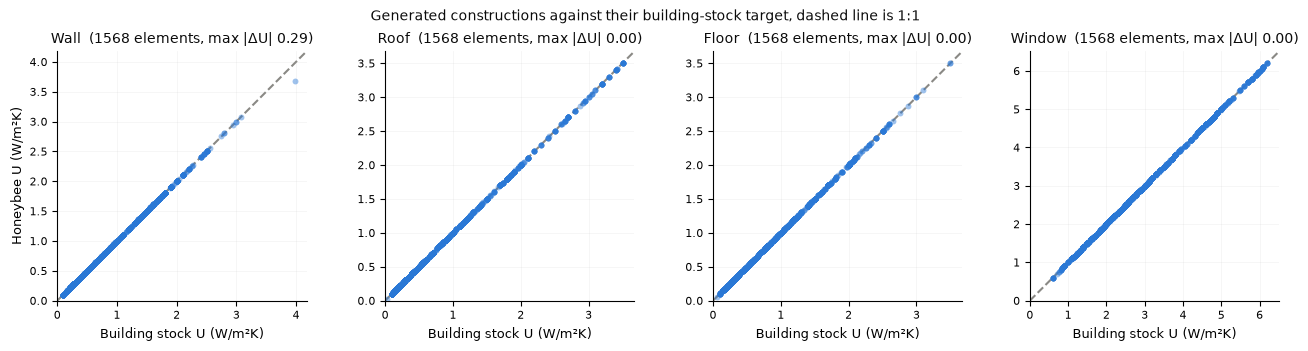

,element_code,elements,stock_u_mean,honeybee_u_mean,mean_abs_diff,max_abs_diff
0,FLOOR,1568,0.854,0.854,0.0,0.00
1,ROOF,1568,0.826,0.826,0.0,0.00
2,WALL,1568,0.928,0.928,0.0,0.29
3,WINDOW,1568,2.823,2.823,0.0,0.00


In [13]:
# Every element that carries a target U-value must have come out of Part 2 complete.
covered = materials_df["u_value"].notna()
complete = materials_df[HONEYBEE_COLUMNS].notna().all(axis=1)
if not (covered == (covered & complete)).all():
    missing = materials_df.loc[covered & ~complete, MATERIAL_KEYS]
    raise RuntimeError(
        f"{len(missing)} elements with a target U-value have incomplete Honeybee results\n"
        f"{missing.head().to_string(index=False)}"
    )

qa = (
    materials_df.loc[covered]
    .merge(lookups["element_code"], on="element_id", how="left", validate="many_to_one")
    .assign(abs_diff=lambda frame: (frame["honeybee_u_value"] - frame["u_value"]).abs())
)

# One panel per element, so a single hue carries no identity and needs no legend.
SERIES = "#2a78d6"
REFERENCE = "#8a8985"
INK = "#0b0b0b"

element_codes = list(elements_df["code"])
fig, axes = plt.subplots(1, len(element_codes), figsize=(3.3 * len(element_codes), 3.4),
                         constrained_layout=True)

for ax, element_code in zip(np.atleast_1d(axes), element_codes):
    panel = qa[qa["element_code"] == element_code]
    limit = max(panel["u_value"].max(), panel["honeybee_u_value"].max()) * 1.05

    ax.plot([0, limit], [0, limit], color=REFERENCE, linewidth=1.5, linestyle="--", zorder=1)
    ax.scatter(panel["u_value"], panel["honeybee_u_value"], s=18, color=SERIES,
               alpha=0.45, linewidths=0, zorder=2)

    ax.set_title(f"{element_code.title()}  ({len(panel)} elements, "
                 f"max |\u0394U| {panel['abs_diff'].max():.2f})", fontsize=10, color=INK)
    ax.set_xlabel("Building stock U (W/m\u00b2K)", fontsize=9)
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.15, linewidth=0.5)
    ax.tick_params(labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

np.atleast_1d(axes)[0].set_ylabel("Honeybee U (W/m\u00b2K)", fontsize=9)
fig.suptitle("Generated constructions against their building-stock target, dashed line is 1:1",
             fontsize=10, color=INK)
plt.show()

qa.groupby("element_code", as_index=False).agg(
    elements=("u_value", "size"),
    stock_u_mean=("u_value", "mean"),
    honeybee_u_mean=("honeybee_u_value", "mean"),
    mean_abs_diff=("abs_diff", "mean"),
    max_abs_diff=("abs_diff", "max"),
).round(3)

## Round and save the archetype bundle

Numbers are rounded to two decimals, in the columns and inside the Honeybee JSON, so the stored
values do not carry meaningless precision from the R-value arithmetic.

**Outputs**
`data/interim/archetypes.pkl`, holding the four dimension tables, the cities, and the materials
table enriched with its Honeybee constructions. `BEM4AI_5_BEMModels.ipynb` needs only this file.


In [14]:
# Two decimals everywhere: the R-value arithmetic carries more precision than the source has.
generated_rows = materials_df["honeybee_material"].notna()
for column in HONEYBEE_JSON:
    materials_df.loc[generated_rows, column] = materials_df.loc[generated_rows, column].map(
        lambda value: round_floats(value, 2)
    )
for column in ("u_value", *HONEYBEE_NUMERIC):
    materials_df[column] = pd.to_numeric(materials_df[column], errors="coerce").round(2)

archetypes = {
    "countries": countries_df,
    "building_types": building_types_df,
    "age_classes": age_classes_df,
    "elements": elements_df,
    "cities": cities_df,
    "materials": materials_df.sort_values(MATERIAL_KEYS).reset_index(drop=True),
}
pd.to_pickle(archetypes, ARCHETYPES_PKL)

print(f"Saved {display_path(ARCHETYPES_PKL)} "
      f"({ARCHETYPES_PKL.stat().st_size / 1e6:.2f} MB)")
for name, table in archetypes.items():
    print(f"  {name:<15} {len(table):>5} rows | {', '.join(table.columns)}")

Saved data/interim/archetypes.pkl (2.10 MB)
  countries          28 rows | id, name
  building_types      8 rows | id, code, label, sector
  age_classes         7 rows | id, label, start_year, end_year
  elements            4 rows | id, code, label
  cities            745 rows | id, country_id, name, city_key
  materials        6272 rows | country_id, building_type_id, age_class_id, element_id, u_value, materials, methodologies, honeybee_material, honeybee_construction, honeybee_u_value, u_diff
